<a href="https://colab.research.google.com/github/zoranmrsa/FirstRepository/blob/main/AlphaFold2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Instalacija ColabFold
import os, sys

# Instaliraj ColabFold
os.system("pip install -q --no-warn-conflicts \
  'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
os.system("pip install -q --upgrade tensorflow")
os.system("pip install -q silence_tensorflow")
os.system("pip install -q --upgrade 'jax[cuda12_pip]' \
  -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")

print("✅ Instalacija gotova")

✅ Instalacija gotova


In [2]:
import requests, os, time

jobname = "GBM_trimmed"
os.makedirs(jobname, exist_ok=True)

session = requests.Session()
session.headers.update({"User-Agent": "colabfold-helper/1.0"})

def get_json(uniprot_id, retries=3, backoff=1.0):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
    for attempt in range(retries):
        try:
            r = session.get(url, timeout=20)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt + 1 == retries:
                raise
            time.sleep(backoff * (attempt + 1))

def get_fasta_seq(uniprot_id):
    url = f"https://www.uniprot.org/uniprot/{uniprot_id}.fasta"
    r = session.get(url, timeout=20)
    r.raise_for_status()
    lines = r.text.splitlines()
    return "".join(lines[1:])

def extract_ecd_from_json(j):
    full_seq = j['sequence']['value']
    signal_end_1 = None
    tm_first_start_1 = None
    for feat in j.get('features', []):
        t = feat.get('type', '').lower()
        loc = feat.get('location', {})
        start_val = loc['start'].get('value') if isinstance(loc.get('start'), dict) else None
        end_val   = loc['end'].get('value')   if isinstance(loc.get('end'),   dict) else None
        if isinstance(start_val, str): start_val = int(start_val)
        if isinstance(end_val,   str): end_val   = int(end_val)
        if t == 'signal' and end_val is not None:
            signal_end_1 = end_val
        if t == 'transmembrane' and start_val is not None:
            if tm_first_start_1 is None or start_val < tm_first_start_1:
                tm_first_start_1 = start_val
    ecd_start_idx = signal_end_1 if signal_end_1 is not None else 0
    if tm_first_start_1 is not None:
        ecd_end_idx = tm_first_start_1 - 2
        if ecd_end_idx < ecd_start_idx:
            ecd_end_idx = len(full_seq) - 1
    else:
        ecd_end_idx = len(full_seq) - 1
    ecd_seq = full_seq[ecd_start_idx: ecd_end_idx + 1]
    return full_seq, ecd_seq, ecd_start_idx, ecd_end_idx, signal_end_1, tm_first_start_1

# UniProt ID-ovi
proteins = {
    "CLIC1": "P45736",
    "OSMR":  "Q99650",
    "EGFR":  "P00533",
}

fetched = {}
print("Fetching sequences from UniProt...")
for name, uid in proteins.items():
    j = get_json(uid)
    full, ecd, ecd_si, ecd_ei, sig_end, tm_start = extract_ecd_from_json(j)
    fetched[name] = {
        "uniprot": uid, "full_seq": full, "ecd_seq": ecd,
        "ecd_start_idx": ecd_si, "ecd_end_idx": ecd_ei,
        "signal_end_1based": sig_end, "tm_start_1based": tm_start,
    }
    print(f"  {name} ({uid}): full={len(full)}, ECD={len(ecd)}, TM_start={tm_start}")

# EGFRvIII: delecija AA 6-273 (0-based: 5..272)
del_start_0, del_end_0 = 5, 272
egfr_full = fetched["EGFR"]["full_seq"]
egfrviii_full = egfr_full[:del_start_0] + egfr_full[del_end_0 + 1:]
fetched["EGFR"]["viii_full_seq"] = egfrviii_full

# EGFRvIII ECD
egfr_info = fetched["EGFR"]
orig_ecd  = egfr_info["ecd_seq"]
si, ei    = egfr_info["ecd_start_idx"], egfr_info["ecd_end_idx"]
ov_s = max(si, del_start_0)
ov_e = min(ei, del_end_0)
if ov_s <= ov_e:
    rs, re = ov_s - si, ov_e - si
    egfrviii_ecd = orig_ecd[:rs] + orig_ecd[re + 1:]
else:
    egfrviii_ecd = orig_ecd
fetched["EGFR"]["viii_ecd_seq"] = egfrviii_ecd
print(f"\nEGFRvIII: full={len(egfrviii_full)}, ECD={len(egfrviii_ecd)}")

# Trimmed sekvence (samo ECD)
seqs_trimmed = {
    "CLIC1":    fetched["CLIC1"]["ecd_seq"],
    "OSMR":     fetched["OSMR"]["ecd_seq"],
    "EGFRvIII": fetched["EGFR"]["viii_ecd_seq"],
}

# Tetramer CSV: CLIC1:OSMR:EGFRvIII:EGFRvIII
tetramer_seq = ":".join([seqs_trimmed["CLIC1"], seqs_trimmed["OSMR"],
                          seqs_trimmed["EGFRvIII"], seqs_trimmed["EGFRvIII"]])
tetramer_csv = os.path.join(jobname, f"{jobname}_tetramer.csv")
with open(tetramer_csv, "w") as f:
    f.write("id,sequence\n")
    f.write(f"{jobname},{tetramer_seq}\n")

# Pairwise CSV
names = list(seqs_trimmed.keys())
pairwise_csv = os.path.join(jobname, f"{jobname}_pairwise.csv")
with open(pairwise_csv, "w") as f:
    f.write("id,sequence\n")
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            idname = f"{names[i]}_{names[j]}"
            seq = seqs_trimmed[names[i]] + ":" + seqs_trimmed[names[j]]
            f.write(f"{idname},{seq}\n")

total_res = sum(len(s) for s in tetramer_seq.split(":"))
print(f"\nTetramer CSV: {tetramer_csv}  (ukupno {total_res} AA)")
print(f"Pairwise CSV: {pairwise_csv}")
for k, v in seqs_trimmed.items():
    print(f"  {k}: {len(v)} aa")
if total_res > 2500:
    print("⚠️  WARNING: >2500 AA — rizik OOM. Koristi pairwise.")
else:
    print("✅ Ukupno AA OK za Colab GPU.")

Fetching sequences from UniProt...
  CLIC1 (P45736): full=117, ECD=117, TM_start=None
  OSMR (Q99650): full=979, ECD=713, TM_start=741
  EGFR (P00533): full=1210, ECD=621, TM_start=646

EGFRvIII: full=942, ECD=372

Tetramer CSV: GBM_trimmed/GBM_trimmed_tetramer.csv  (ukupno 1574 AA)
Pairwise CSV: GBM_trimmed/GBM_trimmed_pairwise.csv
  CLIC1: 117 aa
  OSMR: 713 aa
  EGFRvIII: 372 aa
✅ Ukupno AA OK za Colab GPU.


In [3]:
import os, sys

# ← PROMIJENI OVO: True = pairwise (brže), False = tetramer
use_pairwise = True

trimmed_folder = "GBM_trimmed"
tetramer_csv_path = os.path.join(trimmed_folder, "GBM_trimmed_tetramer.csv")
pairwise_csv_path = os.path.join(trimmed_folder, "GBM_trimmed_pairwise.csv")

if use_pairwise:
    queries_path = pairwise_csv_path
    jobname      = "GBM_trimmed_pairwise_run"
else:
    queries_path = tetramer_csv_path
    jobname      = "GBM_trimmed_tetramer_run"

# ColabFold postavke
model_type                   = "alphafold2_multimer_v3"
msa_mode                     = "mmseqs2_uniref_env"
pair_mode                    = "unpaired_paired"
pairing_strategy             = "greedy"
num_recycles                 = 3
num_relax                    = 0
num_seeds                    = 1
use_dropout                  = False
max_msa                      = "512:1024"
dpi                          = 150
save_all                     = False
save_recycles                = False
use_templates                = False
custom_template_path         = None
relax_max_iterations         = 200
recycle_early_stop_tolerance = 0.0
calc_extra_ptm               = False
use_amber                    = num_relax > 0
python_version               = f"{sys.version_info.major}.{sys.version_info.minor}"

# Provjera
if not os.path.exists(queries_path):
    raise FileNotFoundError(f"{queries_path} ne postoji. Pokreni Ćeliju 2 prvo!")

with open(queries_path) as fh:
    lines = fh.read().strip().splitlines()
print("CSV preview:")
for ln in lines[:4]:
    print(" ", ln[:120])

last_seq = lines[-1].split(",", 1)[1]
total_res = sum(len(s) for s in last_seq.split(":"))
print(f"\nUkupno AA u zadnjem redu: {total_res}")
print("✅ Varijable postavljene. Pokreni Ćeliju 4 (Run Prediction).")

CSV preview:
  id,sequence
  CLIC1_OSMR,MIDKIKSNARDLRRNLTLQERKLWRYLRSRRFSDFKFRRQHPVGSYILDFACCSARVVVELDGGQHDLAVAYDSRRTSWLESQGWTVLRFWNNEIDCNEETVLENILQE
  CLIC1_EGFRvIII,MIDKIKSNARDLRRNLTLQERKLWRYLRSRRFSDFKFRRQHPVGSYILDFACCSARVVVELDGGQHDLAVAYDSRRTSWLESQGWTVLRFWNNEIDCNEETVLEN
  OSMR_EGFRvIII,ERLPLTPVSLKVSTNSTRQSLHLQWTVHNLPYHQELKMVFQIQISRIETSNVIWVGNYSTTVKWNQVLHWSWESELPLECATHFVRIKSLVDDAKFPEPNFWSNWS

Ukupno AA u zadnjem redu: 1085
✅ Varijable postavljene. Pokreni Ćeliju 4 (Run Prediction).


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


🔧 3 modela, 3 recycles, model: alphafold2_multimer_v3


2026-06-19 08:29:12,071 Running on GPU
2026-06-19 08:29:12,475 Found 5 citations for tools or databases
2026-06-19 08:29:12,475 Query 1/3: CLIC1_EGFRvIII (length 489)


PENDING:   0%|          | 0/300 [elapsed: 00:00 remaining: ?]

2026-06-19 08:29:12,769 Sleeping for 10s. Reason: PENDING


...

RUNNING:   5%|▌         | 15/300 [elapsed: 00:15 remaining: 05:00]

2026-06-19 08:30:14,043 Sleeping for 6s. Reason: RUNNING


RUNNING:   7%|▋         | 21/300 [elapsed: 00:22 remaining: 04:53]

2026-06-19 08:30:20,331 Sleeping for 9s. Reason: RUNNING


COMPLETE: 100%|██████████| 300/300 [elapsed: 00:31 remaining: 00:00]


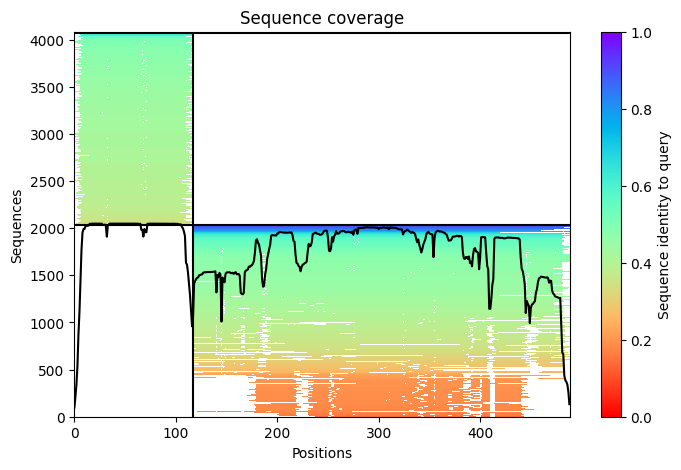

2026-06-19 08:30:34,873 Could not predict CLIC1_EGFRvIII. Not Enough GPU memory? INVALID_ARGUMENT: Unexpected PJRT_FFI_UserData_Add_Args size: expected 48, got 40. The plugin is likely built with a later version than the framework. This plugin is built with PJRT API version 0.76.
2026-06-19 08:30:34,874 Query 2/3: CLIC1_OSMR (length 830)


PENDING:   0%|          | 0/300 [elapsed: 00:00 remaining: ?]

2026-06-19 08:30:35,153 Sleeping for 10s. Reason: PENDING


RUNNING:   3%|▎         | 10/300 [elapsed: 00:10 remaining: 05:05]

2026-06-19 08:30:45,427 Sleeping for 6s. Reason: RUNNING


...

RUNNING:  50%|█████     | 151/300 [elapsed: 02:38 remaining: 02:37]

2026-06-19 08:37:20,178 Sleeping for 7s. Reason: RUNNING


RUNNING:  53%|█████▎    | 158/300 [elapsed: 02:45 remaining: 02:29]

2026-06-19 08:37:27,460 Sleeping for 10s. Reason: RUNNING


COMPLETE: 100%|██████████| 300/300 [elapsed: 02:56 remaining: 00:00]


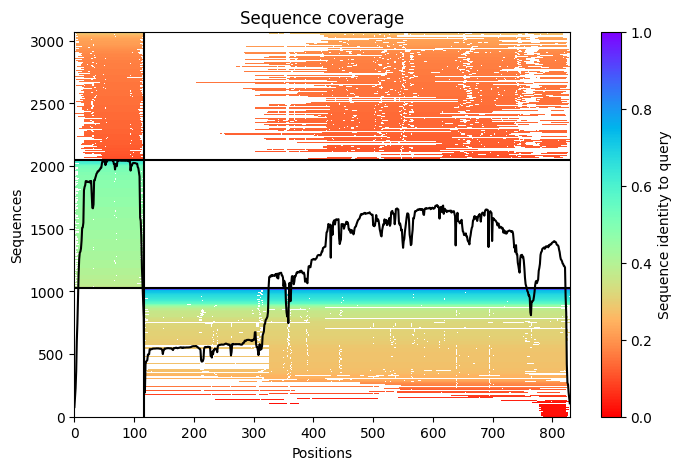

2026-06-19 08:37:41,613 Could not predict CLIC1_OSMR. Not Enough GPU memory? INVALID_ARGUMENT: Unexpected PJRT_FFI_UserData_Add_Args size: expected 48, got 40. The plugin is likely built with a later version than the framework. This plugin is built with PJRT API version 0.76.
2026-06-19 08:37:41,614 Query 3/3: OSMR_EGFRvIII (length 1085)


PENDING:   0%|          | 0/300 [elapsed: 00:00 remaining: ?]

2026-06-19 08:37:41,960 Sleeping for 6s. Reason: PENDING


RUNNING:   2%|▏         | 6/300 [elapsed: 00:06 remaining: 05:23]

2026-06-19 08:37:48,228 Sleeping for 9s. Reason: RUNNING


...

RUNNING:  51%|█████▏    | 154/300 [elapsed: 02:39 remaining: 02:30]

2026-06-19 08:44:34,214 Sleeping for 9s. Reason: RUNNING


RUNNING:  54%|█████▍    | 163/300 [elapsed: 02:49 remaining: 02:21]

2026-06-19 08:44:43,482 Sleeping for 5s. Reason: RUNNING


COMPLETE: 100%|██████████| 300/300 [elapsed: 02:55 remaining: 00:00]


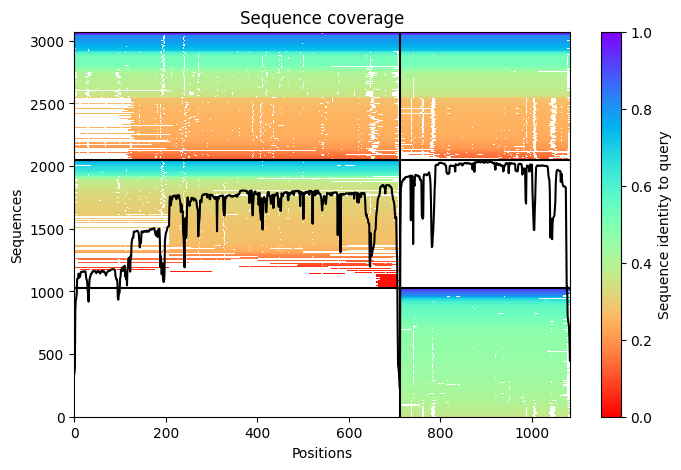

2026-06-19 08:44:52,196 Could not predict OSMR_EGFRvIII. Not Enough GPU memory? INVALID_ARGUMENT: Unexpected PJRT_FFI_UserData_Add_Args size: expected 48, got 40. The plugin is likely built with a later version than the framework. This plugin is built with PJRT API version 0.76.
2026-06-19 08:44:52,196 Done

✅ Gotovo! Rezultati: GBM_trimmed_pairwise_run/
📦 ZIP: GBM_trimmed_pairwise_run.result.zip


In [4]:
#@title Run Prediction
display_images = True

import sys, os, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2
import numpy as np
import matplotlib.pyplot as plt

try:
    K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
    K80_chk = "0"
if "1" in K80_chk:
    print("WARNING: Tesla K80 — max duljina < 1000 AA")
    os.environ.pop("TF_FORCE_UNIFIED_MEMORY", None)
    os.environ.pop("XLA_PYTHON_CLIENT_MEM_FRACTION", None)

from colabfold.colabfold import plot_protein

if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
    if display_images:
        plot_msa_v2(input_features)
        plt.show(); plt.close()

def prediction_callback(protein_obj, length, prediction_result, input_features, mode):
    model_name, relaxed = mode
    if not relaxed and display_images:
        fig = plot_protein(protein_obj, Ls=length, dpi=150)
        plt.show(); plt.close()

# Broj modela (modificirano: 3 umjesto 5 za brzinu)
num_models = 3

result_dir   = jobname
log_filename = os.path.join(jobname, "log.txt")
os.makedirs(jobname, exist_ok=True)
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

use_cluster_profile = False if ("multimer" in model_type and max_msa is not None) else True

print(f"🔧 {num_models} modela, {num_recycles} recycles, model: {model_type}")
download_alphafold_params(model_type, Path("."))

results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=num_models,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1, 2, 3, 4, 5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
    calc_extra_ptm=calc_extra_ptm,
)

os.system(f"zip -r {jobname}.result.zip {jobname}")
print(f"\n✅ Gotovo! Rezultati: {jobname}/")
print(f"📦 ZIP: {jobname}.result.zip")